# Experiment 3 — Setup and augmentation of WaRP-C paper
Mohamed Fahmi Ahmed 

From Section 5.2 of the paper:
- **No two-phase training** — all layers unfrozen from epoch 1
- **40 epochs** with lr=0.001 initial
- **ReduceLROnPlateau** scheduler
- **CrossEntropyLoss** standard
- Augmentation: shift/scale/rotate, brightness/contrast, color shift, flips, occlusion mask
- **No MixUp, no EMA, no label smoothing**

Model: EfficientNetV2-M 

## 1 — Imports & Setup

In [1]:
import sys, copy, time, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.amp import GradScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
)
from sklearn.preprocessing import label_binarize

root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Pipeline_.preprocessor import WaRPPreprocessor
from Models.efficientnetv2m import EfficientNetV2M

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device  : cuda
PyTorch : 2.11.0+cu130


## 2 — Hyperparameters

Directly from Section 5.2 of Yudin et al. (2022):

- 40 epochs
- Initial LR = 0.001
- ReduceLROnPlateau — reduces LR when val metric stops improving
- CrossEntropyLoss standard (no label smoothing)
- No EMA, no differential LR, no two-phase training

In [2]:
NUM_EPOCHS   = 40
BATCH_SIZE   = 32
LR           = 1e-3      # Yudin et al. lr=0.001
WEIGHT_DECAY = 0.0       # not mentioned in paper
NUM_CLASSES  = 28

print(f'Epochs     : {NUM_EPOCHS}')
print(f'Batch size : {BATCH_SIZE}')
print(f'LR         : {LR}  (ReduceLROnPlateau)')
print(f'Loss       : CrossEntropyLoss  (no smoothing)')
print(f'EMA        : No')
print(f'Two-phase  : No  (all layers unfrozen from epoch 1)')

Epochs     : 40
Batch size : 32
LR         : 0.001  (ReduceLROnPlateau)
Loss       : CrossEntropyLoss  (no smoothing)
EMA        : No
Two-phase  : No  (all layers unfrozen from epoch 1)


## 3 — Data Pipeline

Minimal preprocessor — no WeightedRandomSampler, no minority augmentation,
no MixUp, no extra transforms. Just resize to 224 and normalize.

Yudin et al. apply their own augmentation manually in the training loop.
We do the same here.

In [3]:
pp = WaRPPreprocessor(
    raw_root       = root / 'Dataset/raw/Warp-C',
    processed_root = root / 'Dataset/processed',
    stats_file     = root / 'Dataset/dataset_stats.json',
    batch_size     = BATCH_SIZE,
    num_workers    = 4,
)

pp.prepare()  # run once

train_loader, test_loader = pp.get_loaders(model_type='efficientnet')

CLASS_NAMES = sorted(
    d.name for d in (root / 'Dataset/processed/train').iterdir() if d.is_dir()
)
print(f'Classes       : {len(CLASS_NAMES)}')
print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

  WaRPPreprocessor.prepare()
  /user/HS401/mf01425/Documents/coursework/Waste-Classification-main/Dataset/processed/ already exists. Pass force=True to recreate.
[get_loaders] model='efficientnet'
  sampler=False  minority_aug=False  mixup=False  pipeline='cnn'
  train=273 batches  test=49 batches  sampler=Uniform (shuffle)
Classes       : 28
Train batches : 273
Test  batches : 49


## 4 — Loss Function

Standard CrossEntropyLoss — exactly as in Yudin et al. (2022).
No class weights, no label smoothing.

In [4]:
criterion = nn.CrossEntropyLoss()
print('Loss : CrossEntropyLoss  (standard, no smoothing, no class weights)')

Loss : CrossEntropyLoss  (standard, no smoothing, no class weights)


## 5 — Augmentation

Exact augmentation from Section 5.2 of the paper, applied to every training batch:

- **Padding + resize** to preserve original aspect ratio (PadToSquare then resize to 224)
- **Random shift/scale/rotate** — shift_limit=0.2, scale_limit=0.2, rotate_limit=90
- **Random brightness/contrast** — p=0.5, brightness_limit=0.1
- **Random RGB color shift** — p=0.5, shift_limit=15 per channel
- **Random horizontal flip** — p=0.5
- **Random vertical flip** — p=0.5
- **Partial occlusion mask** — 20% of image area zeroed randomly

Applied to every batch during training. Test set is never augmented.

In [14]:
def function_augment(imgs: torch.Tensor) -> torch.Tensor:
    B, C, H, W = imgs.shape
    out = []

    for img in imgs:

        # random shift / scale / rotate
        # shift_limit=0.2 -> translate up to 20% of image size
        # scale_limit=0.2 -> scale between 0.8 and 1.2
        # rotate_limit=90 -> rotation up to 90 degrees
        angle = random.uniform(-90, 90)
        scale = random.uniform(0.8, 1.2)
        tx    = int(random.uniform(-0.2, 0.2) * W)
        ty    = int(random.uniform(-0.2, 0.2) * H)
        img   = TF.affine(img, angle=angle, translate=(tx, ty), scale=scale, shear=0)

        # random brightness and contrast — p=0.5, limit=0.1
        if random.random() < 0.5:
            img = TF.adjust_brightness(img, 1 + random.uniform(-0.1, 0.1))
            img = TF.adjust_contrast(img,   random.uniform(0.9, 1.1))

        # random RGB color shift — p=0.5, shift up to 15/255 per channel
        if random.random() < 0.5:
            shift = (torch.rand(3, 1, 1, device=img.device) - 0.5) * 2 * (15 / 255)
            img   = (img + shift).clamp(0, 1)

        # random horizontal flip — p=0.5
        if random.random() < 0.5:
            img = TF.hflip(img)

        # random vertical flip — p=0.5
        if random.random() < 0.5:
            img = TF.vflip(img)

        # partial occlusion mask — zeros 20% of image area
        mask_h = int(H * 0.2 ** 0.5)
        mask_w = int(W * 0.2 ** 0.5)
        top    = random.randint(0, H - mask_h)
        left   = random.randint(0, W - mask_w)
        img[:, top:top + mask_h, left:left + mask_w] = 0.0

        out.append(img)

    return torch.stack(out)

print('augmentation defined')

augmentation defined


## 6 — Model

EfficientNetV2-M with the ImageNet head replaced for WaRP-C.
All layers are **unfrozen from the start** — no two-phase training.

Yudin et al. used EfficientNet-B5 (V1) with the same approach:
load pretrained weights, replace final layer, train end-to-end.

In [15]:
model = EfficientNetV2M(num_classes=NUM_CLASSES, dropout=0.3).to(DEVICE)


with torch.no_grad():
    out = model(torch.zeros(2, 3, 224, 224, device=DEVICE))
print(f'Output shape : {out.shape}  <- expected (2, {NUM_CLASSES})')
print(f'Params       : {model.parameter_counts()}')

Output shape : torch.Size([2, 28])  <- expected (2, 28)
Params       : {'total': 52894224, 'backbone': 52858356, 'head': 35868, 'trainable': 52894224, 'frozen': 0}


## 7 — Training Setup

AdamW on all parameters from epoch 1.

**ReduceLROnPlateau** — reduces LR by factor 0.5 when test accuracy
does not improve for 5 epochs. This is what Yudin et al. describe as
'decreased during the training process if the quality metric on the
validation data was not improving over several epochs.'

AMP for speed

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR, weight_decay=WEIGHT_DECAY,
)

# ReduceLROnPlateau — matches Yudin et al. description
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'max',    # maximise accuracy
    factor   = 0.5,      # halve LR on plateau
    patience = 5,        # wait 5 epochs before reducing
    min_lr   = 1e-6,
)

scaler = GradScaler('cuda', enabled=(DEVICE == 'cuda'))

SAVE_PATH = root / 'Models/weights/efficientnet_exp3_onlysetupaugmentationfrompaper.pth'
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'Optimizer  : AdamW  lr={LR}')
print(f'Scheduler  : ReduceLROnPlateau  patience=5  factor=0.5')
print(f'Checkpoint : {SAVE_PATH}')

Optimizer  : AdamW  lr=0.001
Scheduler  : ReduceLROnPlateau  patience=5  factor=0.5
Checkpoint : /user/HS401/mf01425/Documents/coursework/Waste-Classification-main/Models/weights/efficientnet_yudin_exact.pth


## 8 — Training Loop

Single phase — all layers train from epoch 1.
Augmentation applied to every training batch.

In [ ]:
train_losses, train_accs, test_accs = [], [], []
best_acc = 0.0

print(f'Starting {NUM_EPOCHS} epochs  (single phase, no freezing)\n')

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()
    ep_loss = correct = total_n = 0
    t0 = time.time()

    for imgs, lbls in train_loader:
        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)

        # Yudin et al. augmentation — applied every batch
        imgs = function_augment(imgs)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=DEVICE, enabled=(DEVICE == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, lbls)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        ep_loss += loss.item()
        correct += (logits.argmax(1) == lbls).sum().item()
        total_n += lbls.size(0)

    # evaluate on test set
    model.eval()
    test_correct = test_total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            preds         = model(imgs.to(DEVICE)).argmax(1).cpu()
            test_correct += (preds == lbls).sum().item()
            test_total   += lbls.size(0)
    test_acc = test_correct / test_total * 100

    train_loss = ep_loss / len(train_loader)
    train_acc  = correct / total_n * 100

    # ReduceLROnPlateau steps on test accuracy
    scheduler.step(test_acc)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), SAVE_PATH)
        flag = 'v'
    else:
        flag = ' '

    current_lr = optimizer.param_groups[0]['lr']
    print(f'[{epoch:>3}/{NUM_EPOCHS}]'
          f'  loss={train_loss:.4f}'
          f'  train={train_acc:.1f}%'
          f'  test={test_acc:.1f}%'
          f'  lr={current_lr:.6f}'
          f'  {flag}best={best_acc:.1f}%'
          f'  {time.time()-t0:.0f}s')

print(f'\nDone — best accuracy: {best_acc:.2f}%')
print(f'Saved to: {SAVE_PATH}')

Starting 40 epochs  (single phase, no freezing)

[  1/40]  loss=2.5706  train=25.3%  test=35.4%  lr=0.001000  vbest=35.4%  59s
[  2/40]  loss=2.0852  train=37.0%  test=42.7%  lr=0.001000  vbest=42.7%  57s
[  3/40]  loss=1.9223  train=40.8%  test=49.8%  lr=0.001000  vbest=49.8%  57s
[  4/40]  loss=1.8202  train=43.7%  test=52.7%  lr=0.001000  vbest=52.7%  59s
[  5/40]  loss=1.7582  train=45.2%  test=54.2%  lr=0.001000  vbest=54.2%  59s
[  6/40]  loss=1.7008  train=47.5%  test=52.4%  lr=0.001000   best=54.2%  56s
[  7/40]  loss=1.6567  train=48.0%  test=54.7%  lr=0.001000  vbest=54.7%  58s
[  8/40]  loss=1.5994  train=49.9%  test=60.5%  lr=0.001000  vbest=60.5%  58s
[  9/40]  loss=1.5655  train=50.8%  test=60.5%  lr=0.001000   best=60.5%  55s
[ 10/40]  loss=1.5252  train=52.0%  test=60.9%  lr=0.001000  vbest=60.9%  58s
[ 11/40]  loss=1.5000  train=52.9%  test=62.2%  lr=0.001000  vbest=62.2%  59s
[ 12/40]  loss=1.4640  train=53.5%  test=62.9%  lr=0.001000  vbest=62.9%  59s
[ 13/40]  loss=

## 9 — Training Curves

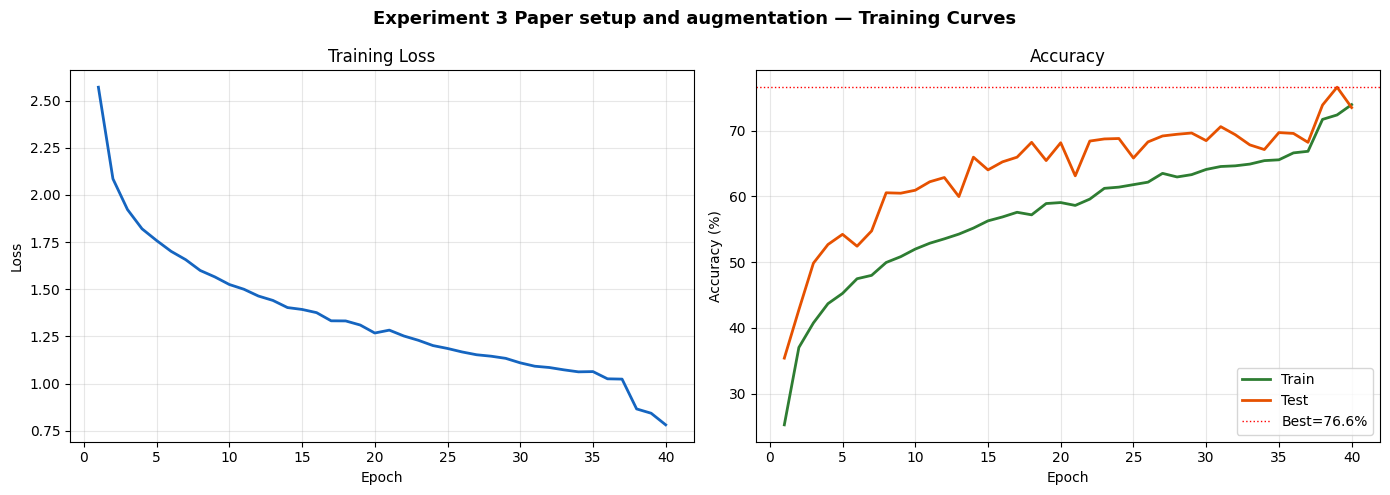

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experiment 3 Paper setup and augmentation — Training Curves', fontsize=13, fontweight='bold')
ep = range(1, NUM_EPOCHS + 1)

axes[0].plot(ep, train_losses, '#1565C0', lw=2)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(ep, train_accs, '#2E7D32', lw=2, label='Train')
axes[1].plot(ep, test_accs,  '#E65100', lw=2, label='Test')
axes[1].axhline(best_acc, color='red', ls=':', lw=1, label=f'Best={best_acc:.1f}%')
axes[1].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
Path(root / 'Dataset/figures').mkdir(parents=True, exist_ok=True)
plt.savefig(root / 'Dataset/figures/ex3_paper_setup_and_augmentation_exact_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 — Evaluation

In [17]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        probs = model(imgs.to(DEVICE)).softmax(dim=1).cpu()
        all_preds.extend(probs.argmax(1).numpy())
        all_labels.extend(lbls.numpy())
        all_probs.extend(probs.numpy())

y_pred  = np.array(all_preds)
y_true  = np.array(all_labels)
y_probs = np.array(all_probs)

acc  = (y_pred == y_true).mean() * 100
f1   = f1_score(y_true, y_pred, average='macro') * 100
prec = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100

y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc   = roc_auc_score(y_bin, y_probs, average='macro', multi_class='ovr') * 100
mAP   = np.mean([
    average_precision_score(y_bin[:, c], y_probs[:, c])
    for c in range(NUM_CLASSES)
]) * 100

print('=' * 52)
print('  Experiment 3 Paper setup and augmentation — Results')
print('=' * 52)
print(f'  Accuracy  : {acc:.2f}%')
print(f'  F1 macro  : {f1:.2f}%')
print(f'  Precision : {prec:.2f}%')
print(f'  Recall    : {rec:.2f}%')
print(f'  AUC macro : {auc:.2f}%')
print(f'  mAP       : {mAP:.2f}%')
print('=' * 52)

  Experiment 3 Paper setup and augmentation — Results
  Accuracy  : 76.60%
  F1 macro  : 74.92%
  Precision : 76.72%
  Recall    : 74.32%
  AUC macro : 98.47%
  mAP       : 82.23%


## 11 — Per-Class Report

In [11]:
df = pd.DataFrame(
    classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        digits=3,
        output_dict=True,
        zero_division=0,
    )
).T
print(df.to_string())

                         precision    recall  f1-score      support
bottle-blue               0.737374  0.701923  0.719212   104.000000
bottle-blue-full          0.800000  0.651163  0.717949    43.000000
bottle-blue5l             0.727273  0.777778  0.751678    72.000000
bottle-blue5l-full        0.941176  0.666667  0.780488    24.000000
bottle-dark               0.861386  0.915789  0.887755    95.000000
bottle-dark-full          0.870968  0.794118  0.830769    34.000000
bottle-green              0.840000  0.851351  0.845638    74.000000
bottle-green-full         0.848485  0.823529  0.835821    34.000000
bottle-milk               0.700000  0.736842  0.717949    57.000000
bottle-milk-full          0.842105  0.761905  0.800000    21.000000
bottle-multicolor         0.454545  0.357143  0.400000    28.000000
bottle-multicolorv-full   0.764706  0.619048  0.684211    21.000000
bottle-oil                0.698113  0.770833  0.732673    48.000000
bottle-oil-full           0.600000  0.750000  0.

## 12 — Confusion Matrix

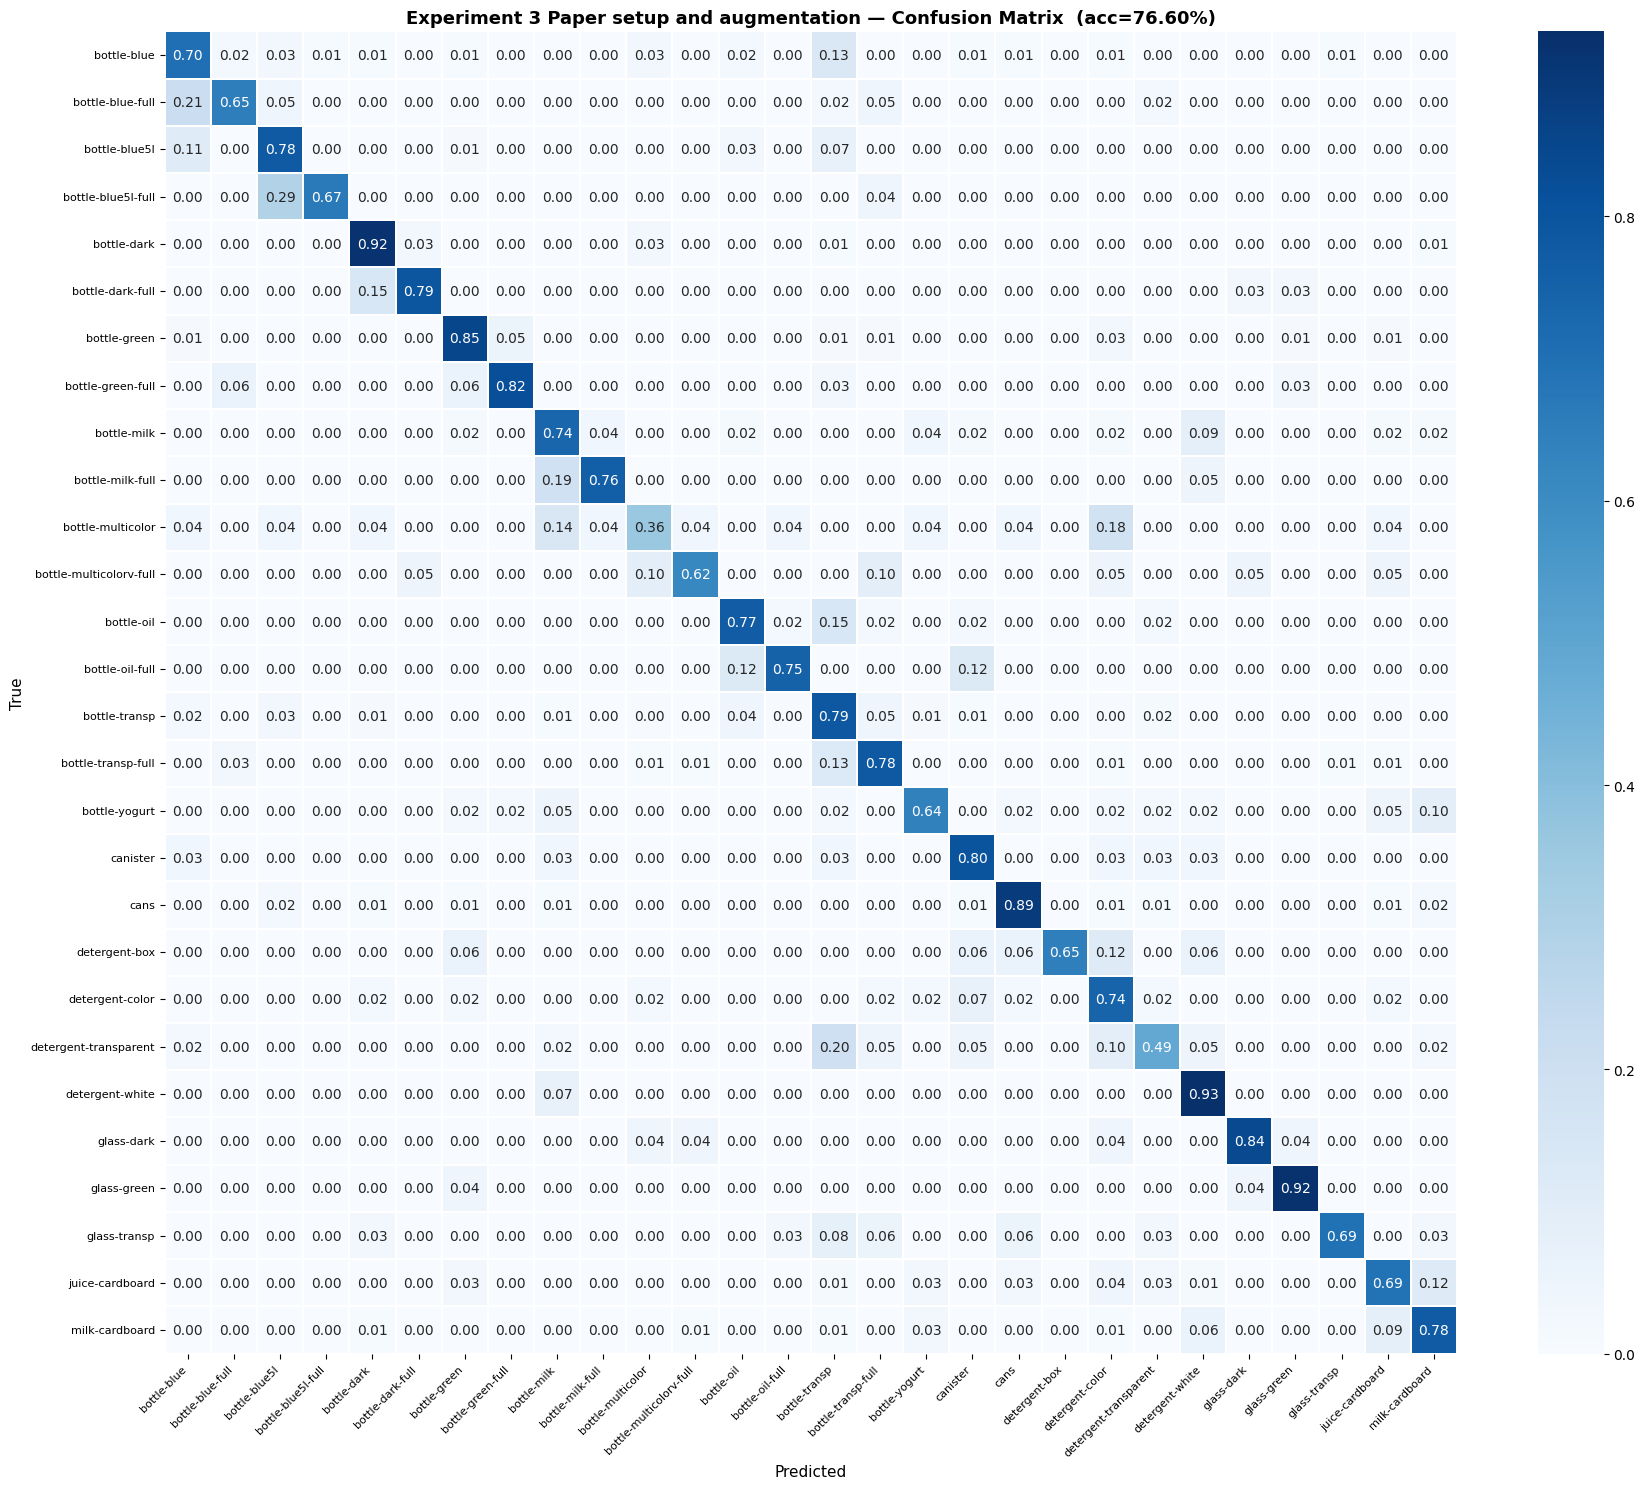

In [19]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title(f'Experiment 3 Paper setup and augmentation — Confusion Matrix  (acc={acc:.2f}%)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(root / 'Dataset/figures/ex3_paper_setup_and_augmentation_exact_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 13 — Summary

In [21]:
c = model.parameter_counts()
print('=' * 60)
print('  Experiment 3 Paper setup and augmentation — Final Summary')
print('=' * 60)
print(f'  Architecture     : EfficientNetV2-M (Yudin used B5)')
print(f'  Total params     : {c["total"]:,}')
print(f'  Epochs           : {NUM_EPOCHS}  (single phase, no freezing)')
print(f'  Best accuracy    : {best_acc:.2f}%')
print()
print(f'  Accuracy         : {acc:.2f}%')
print(f'  F1 macro         : {f1:.2f}%')
print(f'  Precision        : {prec:.2f}%')
print(f'  Recall           : {rec:.2f}%')
print(f'  AUC macro        : {auc:.2f}%')
print(f'  mAP              : {mAP:.2f}%')
print()

  Experiment 3 Paper setup and augmentation — Final Summary
  Architecture     : EfficientNetV2-M (Yudin used B5)
  Total params     : 52,894,224
  Epochs           : 40  (single phase, no freezing)
  Best accuracy    : 76.60%

  Accuracy         : 76.60%
  F1 macro         : 74.92%
  Precision        : 76.72%
  Recall           : 74.32%
  AUC macro        : 98.47%
  mAP              : 82.23%

